# Aadhaar Inclusion Gap Analysis

This notebook analyzes Biometric, Demographic, and Enrolment datasets to identify coverage gaps and update trends.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Set Plotting Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Define Base Paths (using the directory structure found)
BASE_DIR = r"c:\Users\DEEP SARKAR\OneDrive\Desktop\Project"
BIO_PATH = os.path.join(BASE_DIR, "api_data_aadhar_biometric", "api_data_aadhar_biometric", "*.csv")
DEMO_PATH = os.path.join(BASE_DIR, "api_data_aadhar_demographic", "api_data_aadhar_demographic", "*.csv")
ENROL_PATH = os.path.join(BASE_DIR, "api_data_aadhar_enrolment", "api_data_aadhar_enrolment", "*.csv")

OUTPUT_DIR = os.path.join(BASE_DIR, "analysis_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [71]:
def load_data(glob_path):
    files = glob.glob(glob_path)
    if not files:
        print(f"Warning: No files found for {glob_path}")
        return pd.DataFrame()
    
    df_list = []
    for f in files:
        try:
            # Read CSV, assume headers are correct based on inspection
            chunk = pd.read_csv(f)
            df_list.append(chunk)
        except Exception as e:
            print(f"Error reading {f}: {e}")
    
    if df_list:
        return pd.concat(df_list, ignore_index=True)
    return pd.DataFrame()

In [72]:
print("Loading datasets:")
bio_df = load_data(BIO_PATH)
demo_df = load_data(DEMO_PATH)
enrol_df = load_data(ENROL_PATH)

print(f"Biometric Data: {bio_df.shape}")
print(f"Demographic Data: {demo_df.shape}")
print(f"Enrolment Data: {enrol_df.shape}")

Loading datasets:
Biometric Data: (1861108, 6)
Demographic Data: (2071700, 6)
Enrolment Data: (1006029, 7)


In [73]:
# Standardize state names
for df in [bio_df, demo_df, enrol_df]:
    if not df.empty and 'state' in df.columns:
        df['state'] = df['state'].astype(str).str.strip().str.title()
    if not df.empty and 'district' in df.columns:
        df['district'] = df['district'].astype(str).str.strip().str.title()

## 1. Univariate Visualizations

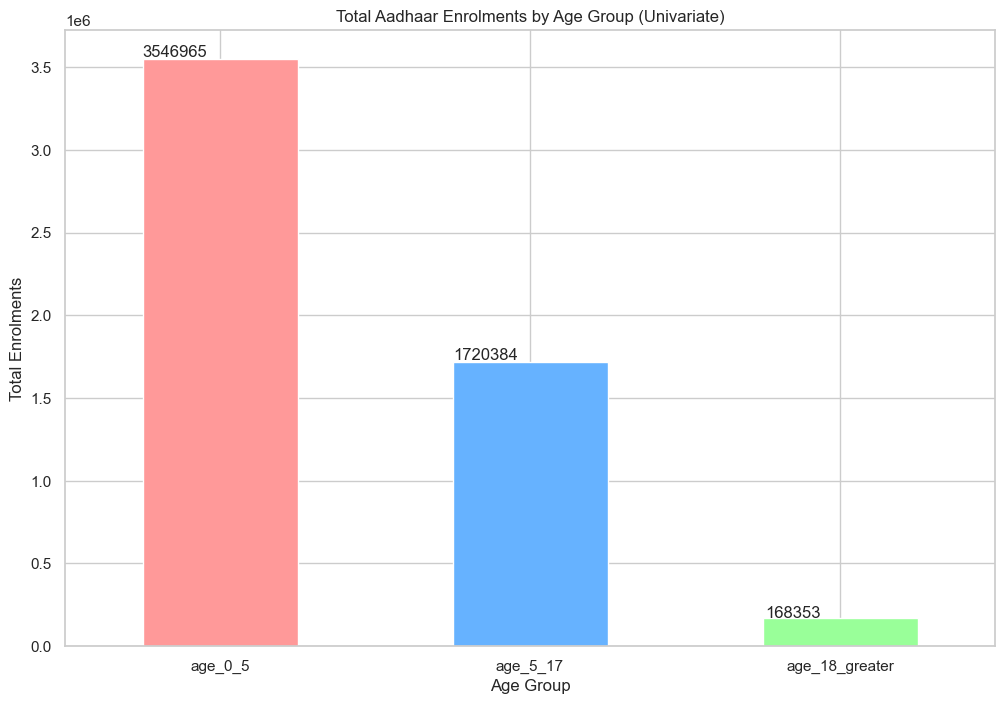

<Figure size 1200x800 with 0 Axes>

In [74]:
# 1.1 Total Enrolment by Age Group
if not enrol_df.empty:
    age_cols = ['age_0_5', 'age_5_17', 'age_18_greater']
    # Ensure numeric
    for col in age_cols:
        enrol_df[col] = pd.to_numeric(enrol_df[col], errors='coerce').fillna(0)
    
    total_enrolments = enrol_df[age_cols].sum()
    
    plt.figure()
    ax = total_enrolments.plot(kind='bar', color=['#FF9999', '#66B2FF', '#99FF99'])
    plt.title('Total Aadhaar Enrolments by Age Group (Univariate)')
    plt.xlabel('Age Group')
    plt.ylabel('Total Enrolments')
    plt.xticks(rotation=0)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), (p.get_x() * 1.005, p.get_height() * 1.005))
    plt.show()
    plt.savefig("Output/Univariate_Analysis/total_aadhar_enrolements.png")

C:\Users\DEEP SARKAR\AppData\Local\Temp\ipykernel_3108\3166892049.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_demo.values, y=state_demo.index, palette='viridis')


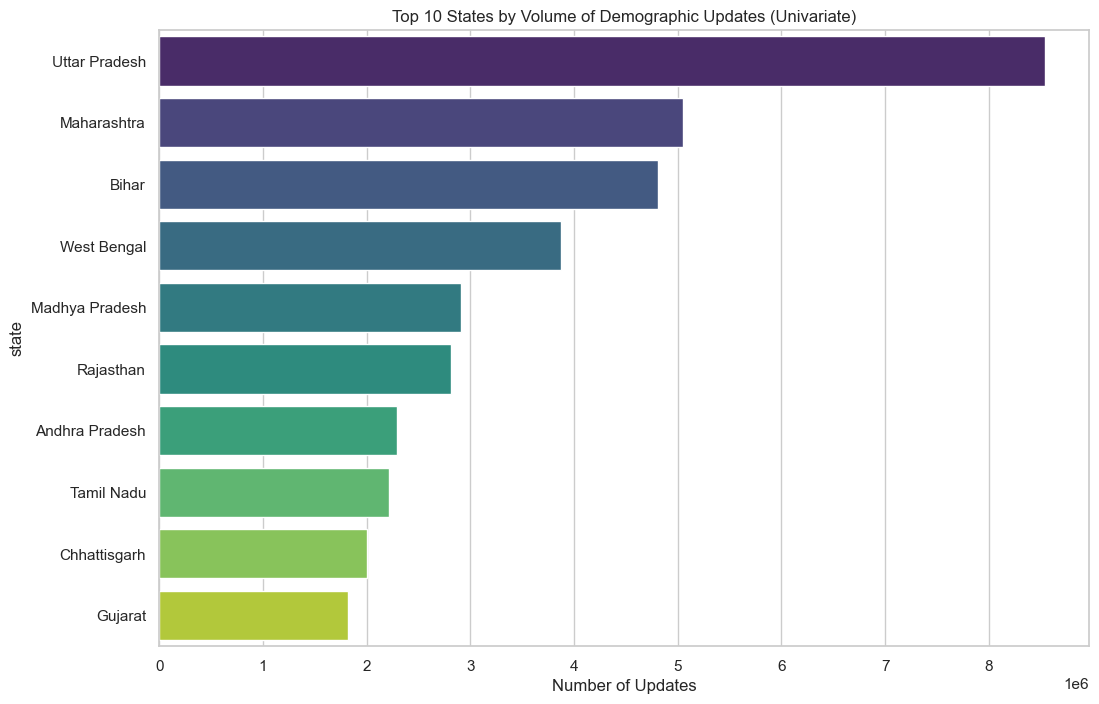

<Figure size 1200x800 with 0 Axes>

In [75]:
# 1.2 Top 10 States by Demographic Updates
if not demo_df.empty:
    demo_cols = ['demo_age_5_17', 'demo_age_17_']
    for col in demo_cols:
        demo_df[col] = pd.to_numeric(demo_df[col], errors='coerce').fillna(0)
    
    demo_df['total_demo_updates'] = demo_df['demo_age_5_17'] + demo_df['demo_age_17_']
    state_demo = demo_df.groupby('state')['total_demo_updates'].sum().nlargest(10)
    
    plt.figure()
    sns.barplot(x=state_demo.values, y=state_demo.index, palette='viridis')
    plt.title('Top 10 States by Volume of Demographic Updates (Univariate)')
    plt.xlabel('Number of Updates')
    plt.show()
    plt.savefig("Output/Univariate_Analysis/total_state_volume.png")

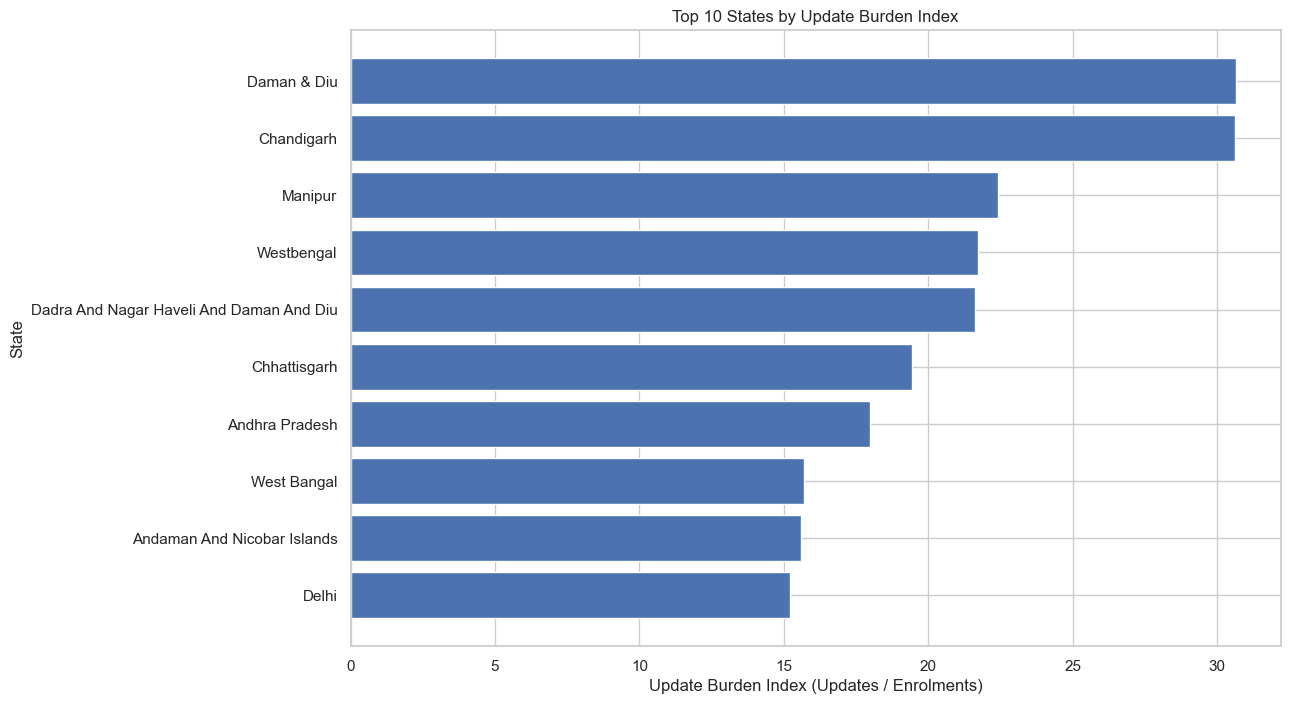

<Figure size 1200x800 with 0 Axes>

In [76]:
# Update Burden Index (Updates / Enrolments) of top 10 states
state_summary = merged_df.groupby("state", as_index=False).agg({
    "total_demo_updates": "sum",
    "total_enrol": "sum"
})

state_summary["update_burden_index"] = state_summary["total_demo_updates"] / state_summary["total_enrol"]

# Take top 10 states
top_states = state_summary.sort_values("update_burden_index", ascending=False).head(10)


plt.figure()
plt.barh(top_states["state"], top_states["update_burden_index"])
plt.title("Top 10 States by Update Burden Index")
plt.xlabel("Update Burden Index (Updates / Enrolments)")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.show()
plt.savefig("Output/Univariate_Analysis/update_burden_index.png")

## 2. Bivariate Visualizations

In [77]:
# Aggregating by State for merged analysis
merged_df = pd.DataFrame()

if not bio_df.empty and not demo_df.empty:
    # Bio Agg
    bio_cols = ['bio_age_5_17', 'bio_age_17_']
    for col in bio_cols:
        bio_df[col] = pd.to_numeric(bio_df[col], errors='coerce').fillna(0)
    bio_state = bio_df.groupby('state')[bio_cols].sum().reset_index()
    bio_state['total_bio'] = bio_state['bio_age_5_17'] + bio_state['bio_age_17_']

    # Demo Agg
    demo_state = demo_df.groupby('state')[['total_demo_updates']].sum().reset_index()

    # Enrol Agg
    enrol_state = enrol_df.groupby('state')[['age_0_5', 'age_5_17', 'age_18_greater']].sum().reset_index()
    enrol_state['total_enrol'] = enrol_state['age_0_5'] + enrol_state['age_5_17'] + enrol_state['age_18_greater']

    # Merge
    merged_df = pd.merge(bio_state, demo_state, on='state', how='inner')
    merged_df = pd.merge(merged_df, enrol_state, on='state', how='inner')


    merged_df["update_total"] = merged_df["total_bio"] + merged_df["total_demo_updates"]
    merged_df["update_burden_index"] = merged_df["update_total"] / merged_df["total_enrol"]
    merged_df["migration_stress_proxy"] = merged_df["total_demo_updates"] / merged_df["update_total"]

    def zscore(s):
        return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

    merged_df["z_enrol"] = zscore(merged_df["total_enrol"])
    merged_df["z_update"] = zscore(merged_df["update_total"])

    merged_df["service_saturation_signal"] = merged_df["z_update"] - merged_df["z_enrol"]





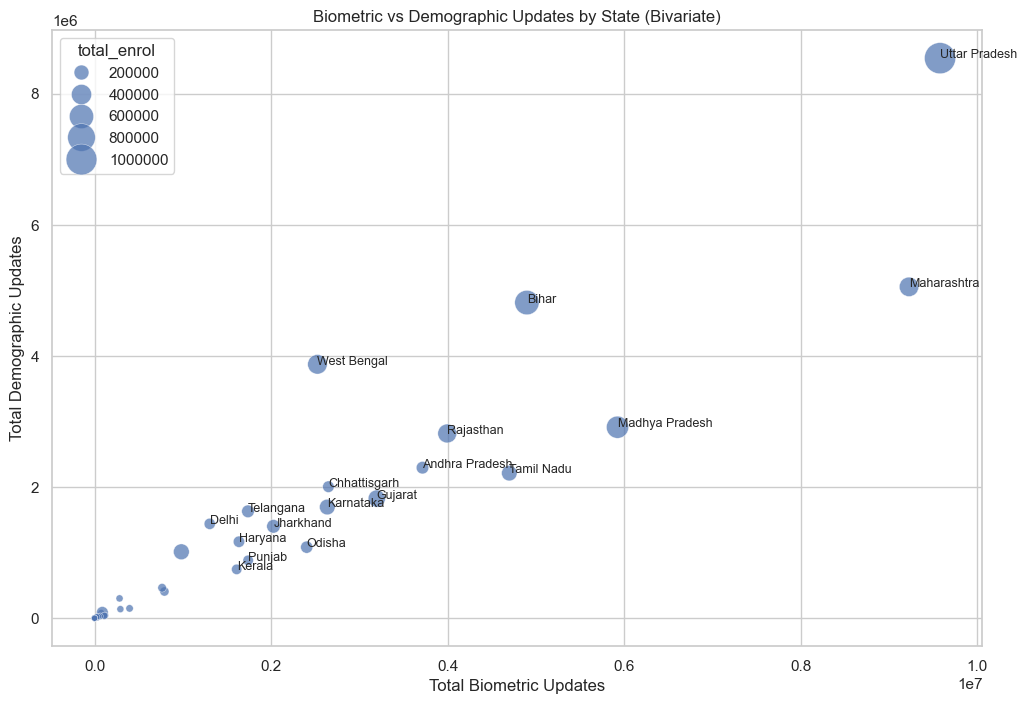

<Figure size 1200x800 with 0 Axes>

In [78]:
# 2.1 Biometric vs Demographic Updates
if not merged_df.empty:
    plt.figure()
    sns.scatterplot(data=merged_df, x='total_bio', y='total_demo_updates', size='total_enrol', sizes=(20, 500), alpha=0.7)
    
    # Label top points
    for i in range(merged_df.shape[0]):
        if merged_df.total_bio.iloc[i] > merged_df.total_bio.mean() or merged_df.total_demo_updates.iloc[i] > merged_df.total_demo_updates.mean():
            plt.text(merged_df.total_bio.iloc[i]+0.2, merged_df.total_demo_updates.iloc[i], merged_df.state.iloc[i], fontsize=9)

    plt.title('Biometric vs Demographic Updates by State (Bivariate)')
    plt.xlabel('Total Biometric Updates')
    plt.ylabel('Total Demographic Updates')
    plt.show()
    plt.savefig("Output/Bivariate_Analysis/biometric_vs_demographic_updates.png")

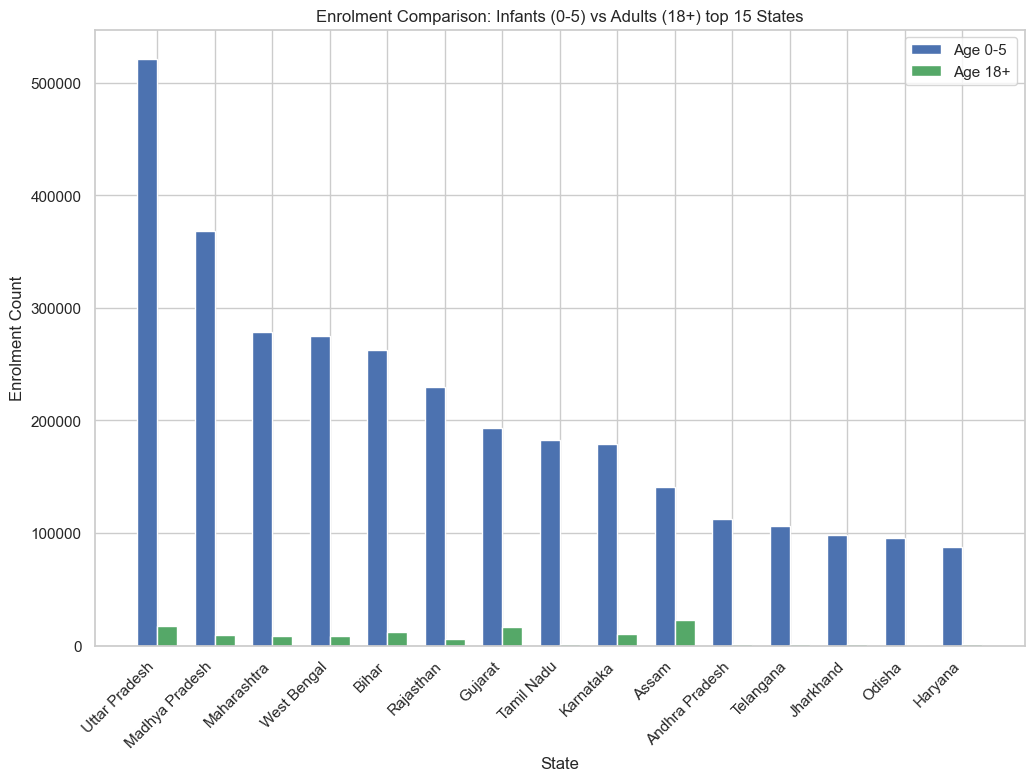

<Figure size 1200x800 with 0 Axes>

In [79]:
# 2.2 Enrolment of 0-5 vs 18+ (Newborn inclusion vs Adult backlog)
if not merged_df.empty:
    plt.figure()
    # Sort by 0-5 enrolment
    merged_df_sorted = merged_df.sort_values('age_0_5', ascending=False).head(15)
    
    # Plotting two bars per state
    bar_width = 0.35
    index = range(len(merged_df_sorted))
    
    p1 = plt.bar(index, merged_df_sorted['age_0_5'], bar_width, label='Age 0-5', color='b')
    p2 = plt.bar([i + bar_width for i in index], merged_df_sorted['age_18_greater'], bar_width, label='Age 18+', color='g')
    
    plt.xlabel('State')
    plt.ylabel('Enrolment Count')
    plt.title('Enrolment Comparison: Infants (0-5) vs Adults (18+) top 15 States')
    plt.xticks([i + bar_width/2 for i in index], merged_df_sorted['state'], rotation=45, ha='right')
    plt.legend()
    plt.show()
    plt.savefig("Output/Bivariate_Analysis/newborn_inclusion_vs_adults_backlog.png")

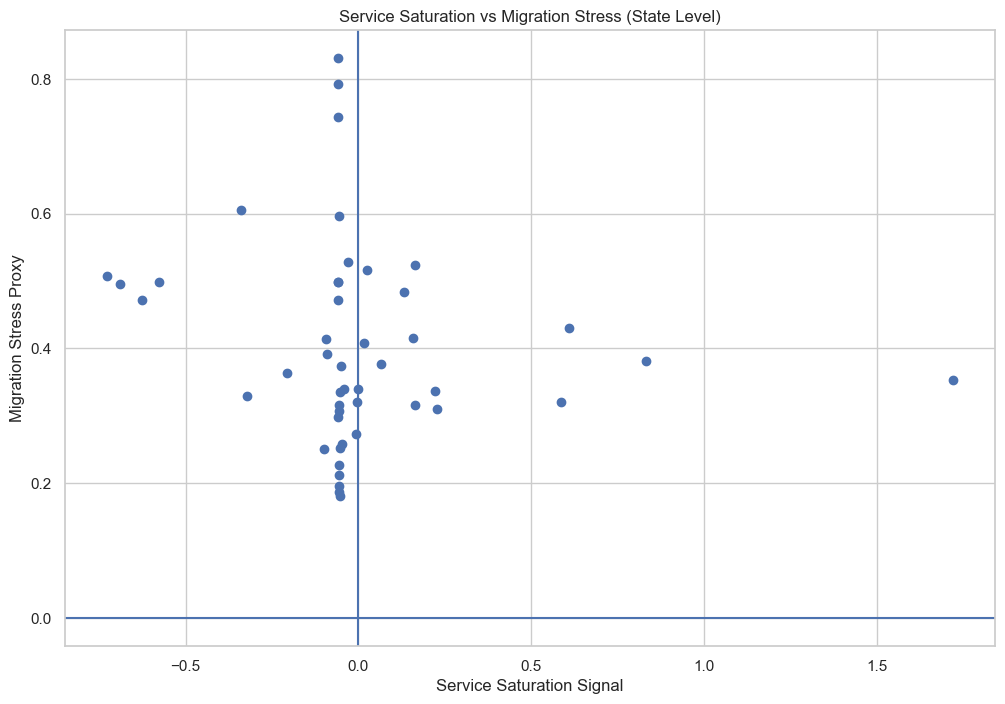

<Figure size 1200x800 with 0 Axes>

In [80]:
#Service saturation vs Migration stress (State Level)
state_metrics = merged_df.groupby("state", as_index=False).agg({
    "service_saturation_signal": "mean",
    "migration_stress_proxy": "mean"
})

plt.figure()
plt.scatter(
    state_metrics["service_saturation_signal"],
    state_metrics["migration_stress_proxy"]
)

plt.axvline(0)  # vertical reference line
plt.axhline(0)  # horizontal reference line

plt.title("Service Saturation vs Migration Stress (State Level)")
plt.xlabel("Service Saturation Signal")
plt.ylabel("Migration Stress Proxy")

plt.show()
plt.savefig("Output/Bivariate_Analysis/service_saturation_vs_migration_stress.png")

## 3. Trivariate Visualizations

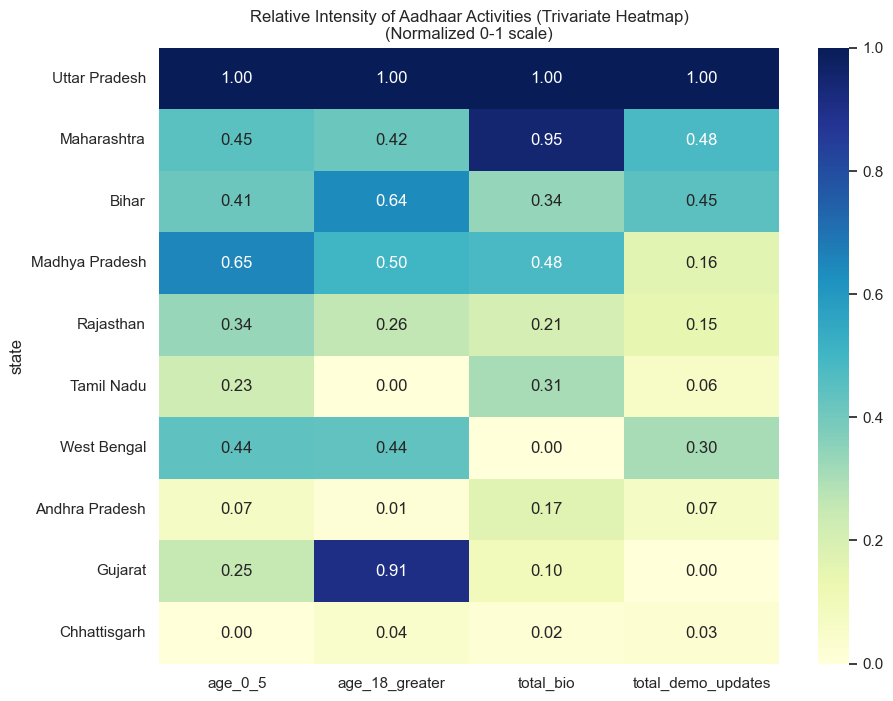

<Figure size 1200x800 with 0 Axes>

In [81]:
# 3.1 Heatmap of Normalized Metrics for Top 10 States
if not merged_df.empty:
    merged_df['total_activity'] = merged_df['total_bio'] + merged_df['total_demo_updates'] + merged_df['total_enrol']
    top_states = merged_df.nlargest(10, 'total_activity').set_index('state')
    
    # Normalize for heatmap comparison
    cols_to_plot = ['age_0_5', 'age_18_greater', 'total_bio', 'total_demo_updates']
    heatmap_data = top_states[cols_to_plot]
    # Simple Min-Max Normalization
    heatmap_data_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data_norm, annot=True, cmap='YlGnBu', fmt='.2f')
    plt.title('Relative Intensity of Aadhaar Activities (Trivariate Heatmap)\n(Normalized 0-1 scale)')
    plt.show()
    plt.savefig("Output/Trivariate_Analysis/heatmaps_of_normalized_metrics.png")

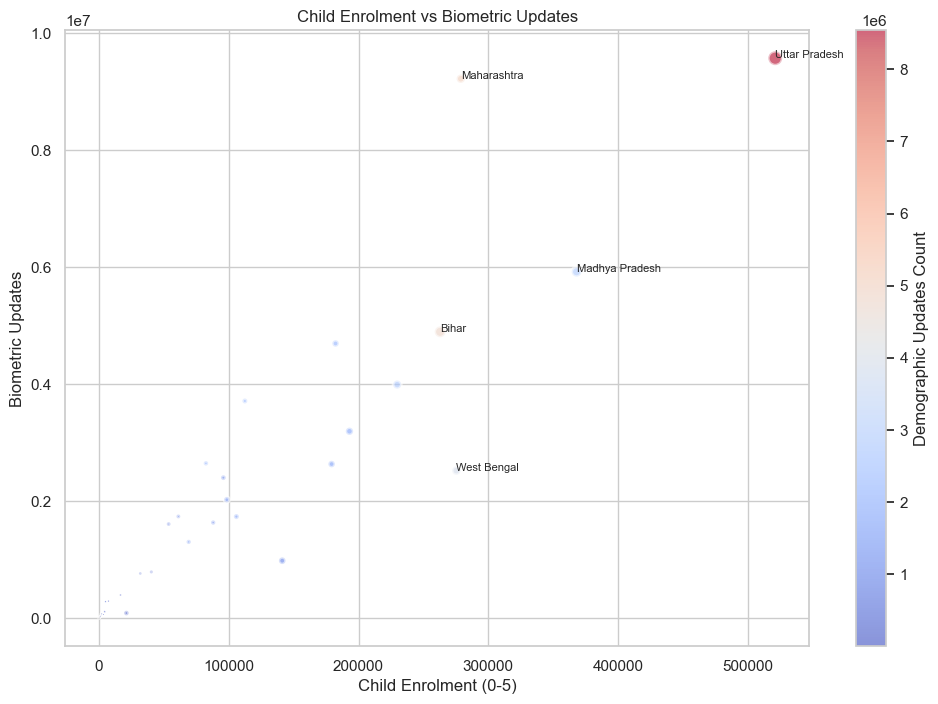

<Figure size 1200x800 with 0 Axes>

In [82]:
# 3.2 Bubble Chart: Bio Updates vs Enrolment 0-5
if not merged_df.empty:
    plt.figure()
    scatter = plt.scatter(
        merged_df['age_0_5'], 
        merged_df['total_bio'], 
        c=merged_df['total_demo_updates'], 
        s=merged_df['total_enrol'] / 10000, # scaling size down
        cmap='coolwarm', 
        alpha=0.6, 
        edgecolors="w", 
        linewidth=2
    )
    plt.colorbar(scatter, label='Demographic Updates Count')
    plt.xlabel('Child Enrolment (0-5)')
    plt.ylabel('Biometric Updates')
    plt.title('Child Enrolment vs Biometric Updates')
    
    # Annotate outliers
    for i in range(merged_df.shape[0]):
        if merged_df.total_enrol.iloc[i] > merged_df.total_enrol.quantile(0.9):
             plt.text(merged_df.age_0_5.iloc[i], merged_df.total_bio.iloc[i], merged_df.state.iloc[i], fontsize=8)

    plt.show()
    plt.savefig("Output/Trivariate_Analysis/child_enrolement_vs_biometric_updates.png")